In [134]:
import numpy as np
import math
from graphviz import Digraph

What do we need to build?

We need to build an end to end training module which performes forward and backward pass on an MLP to find the best fit curve that fits the given data. 
For this, we'll need, a class that handles our data, does backward pass by differentiating. A neuron class which is the most atomic element of the MLP, a layer class and a training loop which fits the data perfectly

In [268]:
# class that encapsulates our data
# does backprop as well

class Value:
    def __init__(self, data, _prev = (), _op = '', label = ''):
        self.data = data
        self._prev = set(_prev)
        self.grad = 0
        self._op = _op
        self.label = label
        self._backward = lambda:None
    
    def __repr__(self):
        return f"Value(data = {self.data})"

    def __add__(self, other):
        if (isinstance(other, float) or isinstance(other, int)): other = Value(other)
        out = self.data + other.data
        out = Value(out, _prev = (self, other), _op = '+')
        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        if (isinstance(other, float) or isinstance(other, int)): other = Value(other)
        out = self.data * other.data
        out = Value(out, _prev = (self, other), _op = '*')
        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __neg__(self):
        return self*-1
    
    def __sub__(self, other):
        if (isinstance(other, float) or isinstance(other, int)): other = Value(other)
        return self+(-other)
    
    def __rsub__(self, other):
        return other+(-self)
    
    def __pow__(self, other):
        assert (isinstance(other, float) or isinstance(other, int))
        out = self.data**other
        out = Value(out, _prev=(self,), _op = f'**{other}')
        def _backward():
            self.grad += other*(self.data**(other - 1))*out.grad
        out._backward = _backward
        return out
    
    def __truediv__(self, other):
        out = self*(other**-1)
        return out
    
    def exp(self):
        out = Value(math.exp(self.data), _prev=(self,), _op = "exp")
        def _backward():
            self.grad += out.data*out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        """
        tanh(x) = (e^2x -1)/(e^2x + 1)
        tanh'(x) = 1 - tanh^2(x)
        """
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, _prev=(self,), _op="tanh")
        def _backward():
            self.grad  += (1 - out.data**2)*out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

We need some utility functions to look at the compute graph created

In [224]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = f"label {n.label} | data {n.data} | grad {n.grad}" , shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [262]:
a = Value(3.0)
a.label = 'a'
b = Value(2.0)
b.label = 'b'
c = b+a
c.label = 'c'
f = Value(-1)
f.label = 'f'
d = f*c
d.label = 'd'
e = d.tanh()
e.label = 'e'
print(e)

Value(data = -0.9999092042625951)


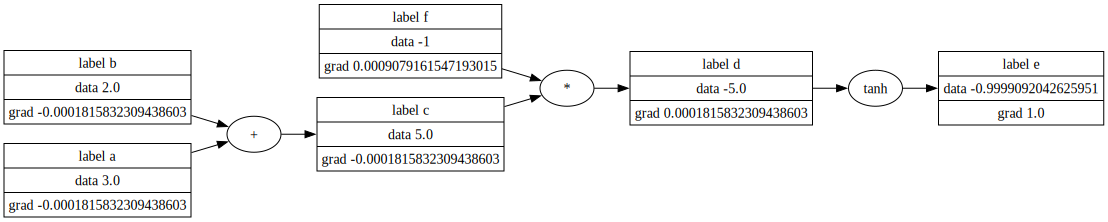

In [265]:
draw_dot(e)

In [264]:
e.backward()

In [228]:
e._backward()

In [205]:
d._backward()

In [207]:
c._backward()

## NN Implementation 

In [305]:
# simple nn 
# assume some input
x = 1
# assume the first layer, 2 nuerons in the first layer, total of 2 weights and 1 bias
# let's inititalize the matrix with Normally distributed weights 
mu = 0; sigma = 1
w11 = Value(np.random.normal(mu, sigma))
w21 = Value(np.random.normal(mu, sigma))
b1 = Value(np.random.normal(mu, sigma))
x11 = w11*x
x11 = x11.tanh()
x21 = w21*x
x21 = x21.tanh()
# final layer, 1 nueron, 2 wieghts
w12 = Value(np.random.normal(mu, sigma))
w22 = Value(np.random.normal(mu, sigma))
y_pred = w12*x11 + w22*x21
y_true = 2
L = (y_true - y_pred)**2


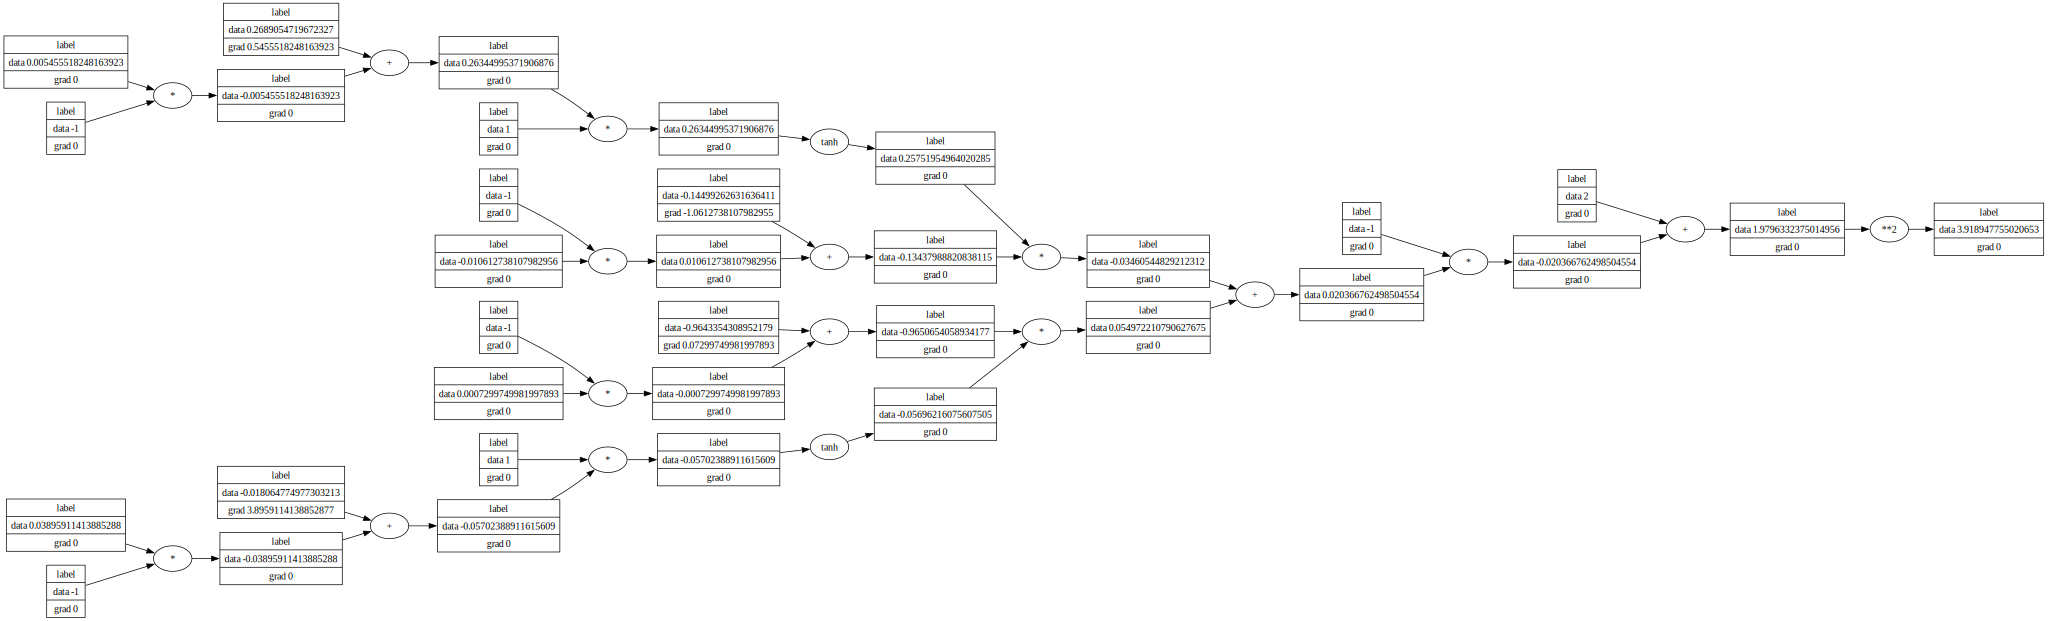

In [313]:
draw_dot(L)

In [315]:
steps = 100
lr = 0.01
for i in range(steps):
    # forward pass 
    x11 = w11*x
    x11 = x11.tanh()
    x21 = w21*x
    x21 = x21.tanh()
    y_pred = w12*x11 + w22*x21
    y_true = 2
    L = (y_true - y_pred)**2
    print(L)
    # zero out the grad 
    w11.grad = 0
    w21.grad = 0
    b1.grad = 0
    w12.grad = 0
    w22.grad = 0
    # backward pass
    L.backward()
    # update the weights
    lr = 0.01
    w11 -= w11.grad*lr
    w21 -= w21.grad*lr
    b1 -= b1.grad*lr
    w12 -= w12.grad*lr
    w22 -= w22.grad*lr


Value(data = 2.620309117172639)
Value(data = 2.517380912836128)
Value(data = 2.418405018405257)
Value(data = 2.3232098115376916)
Value(data = 2.231636389573045)
Value(data = 2.1435368326394633)
Value(data = 2.0587727360574766)
Value(data = 1.977213978956353)
Value(data = 1.8987376969494663)
Value(data = 1.823227428754535)
Value(data = 1.750572409360027)
Value(data = 1.6806669853864893)
Value(data = 1.6134101314154832)
Value(data = 1.5487050490815621)
Value(data = 1.4864588335316298)
Value(data = 1.4265821943881842)
Value(data = 1.3689892205822505)
Value(data = 1.3135971803473894)
Value(data = 1.2603263493033274)
Value(data = 1.209099860931394)
Value(data = 1.1598435748833542)
Value(data = 1.1124859595009684)
Value(data = 1.0669579856853622)
Value(data = 1.0231930298703662)
Value(data = 0.9811267843470436)
Value(data = 0.940697173579044)
Value(data = 0.9018442754587128)
Value(data = 0.8645102466975141)
Value(data = 0.8286392517344369)
Value(data = 0.7941773946932214)
Value(data = 0.7610

# Implement the Nueron Module, Layer Module and MLP Module

In [333]:
# what should nueron module do?
# do forward bias, add it's own bias and activate the neuron
class Neuron:
    def __init__(self, num_ip, act = True):
        self.w = [Value(np.random.normal(0, 1)) for _ in range(num_ip)]
        self.b = Value(np.random.normal(0, 1))
        self.act = act

    
    def __call__(self, x):
        # w.x + b
        z = sum(_w*_x for _w, _x in (list(zip(self.w, x)))) + self.b
        if self.act:
            z = z.tanh()
        return z

x = [1.0, 2.3]
nueron = Neuron(2)
nueron(x)

Value(data = 0.8233499864272449)

In [353]:
# what the layer class should do?
# initializes the nurons of the layer and does the forward pass
class Layer:
    def __init__(self, num_ip, num_op, act = True):
        # init the neurons
        self.num_ip = num_ip
        self.num_op = num_op
        self.n = [Neuron(num_ip, act) for _ in range(num_op)]
    
    def __call__(self, x):
        z = [n_(x) for n_ in self.n]
        return z[0] if len(z) == 1 else z
x = [2,3]
layer = Layer(2, 3)
layer(x)


[Value(data = 0.9966148745126371),
 Value(data = -0.9984709944240459),
 Value(data = -0.7752732283603475)]

In [354]:
# what should the MLP do?
# intializes the layer modules based on the number of layers dfined and number of neurons in each layer
class MLP:
    def __init__(self, num_layers, num_ip, num_neurons):
        self.num_layers = num_layers
        self.num_ip = num_ip
        self.num_neurons = num_neurons
        self.layers = self.init_layers()
        self.params = self.parameters()

    def init_layers(self):
        layers = []
        layer = Layer(num_ip=self.num_ip, num_op=self.num_neurons)
        layers.append(layer)
        for _ in range(1, self.num_layers):
            layers.append(Layer(num_ip=self.num_neurons, num_op=self.num_neurons))
        layers.append(Layer(num_ip=self.num_neurons, num_op=1, act = False))
        return layers
    
    def __call__(self, x):
        # x can be batched as well
        for layer in self.layers:
            out = layer(x)
            x = out
        return x
    
    def parameters(self):
        pass
    

In [356]:
x = [2, 3]
mlp = MLP(2, 2, 3)
out = mlp(x)
out

Value(data = 0.5313490906678289)

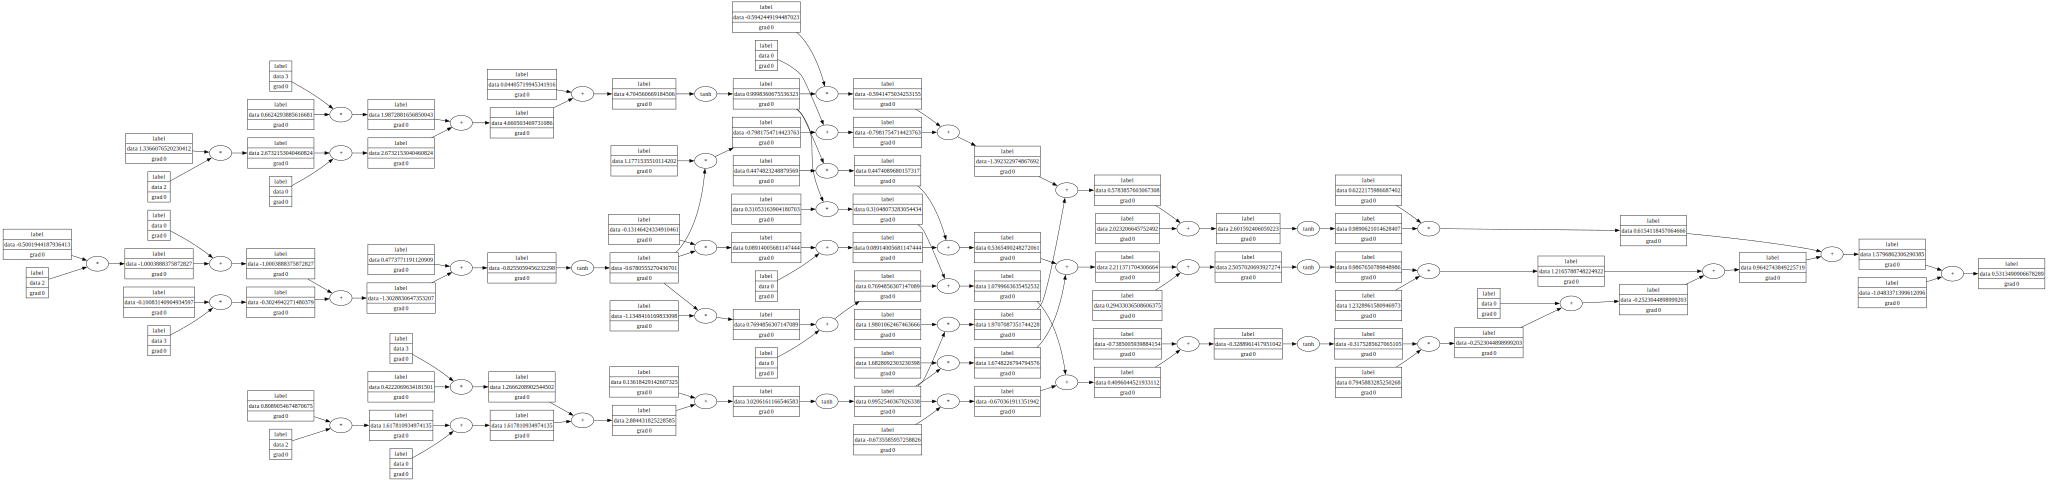

In [357]:
draw_dot(out)

In [374]:
x = [
    [2.0, 1.2, 3.1],
    [1.2, 2.3, 3.0],
    [4.0, 3.1, 6.5]
]
y = [1, 4, 5]
y_pred = [mlp(x_) for x_ in x]
# print(y_pred)
L = sum([(y_ - y_pred_)**2 for y_, y_pred_ in list(zip(y, y_pred))])/len(y)
L

Value(data = 10.638066957860609)

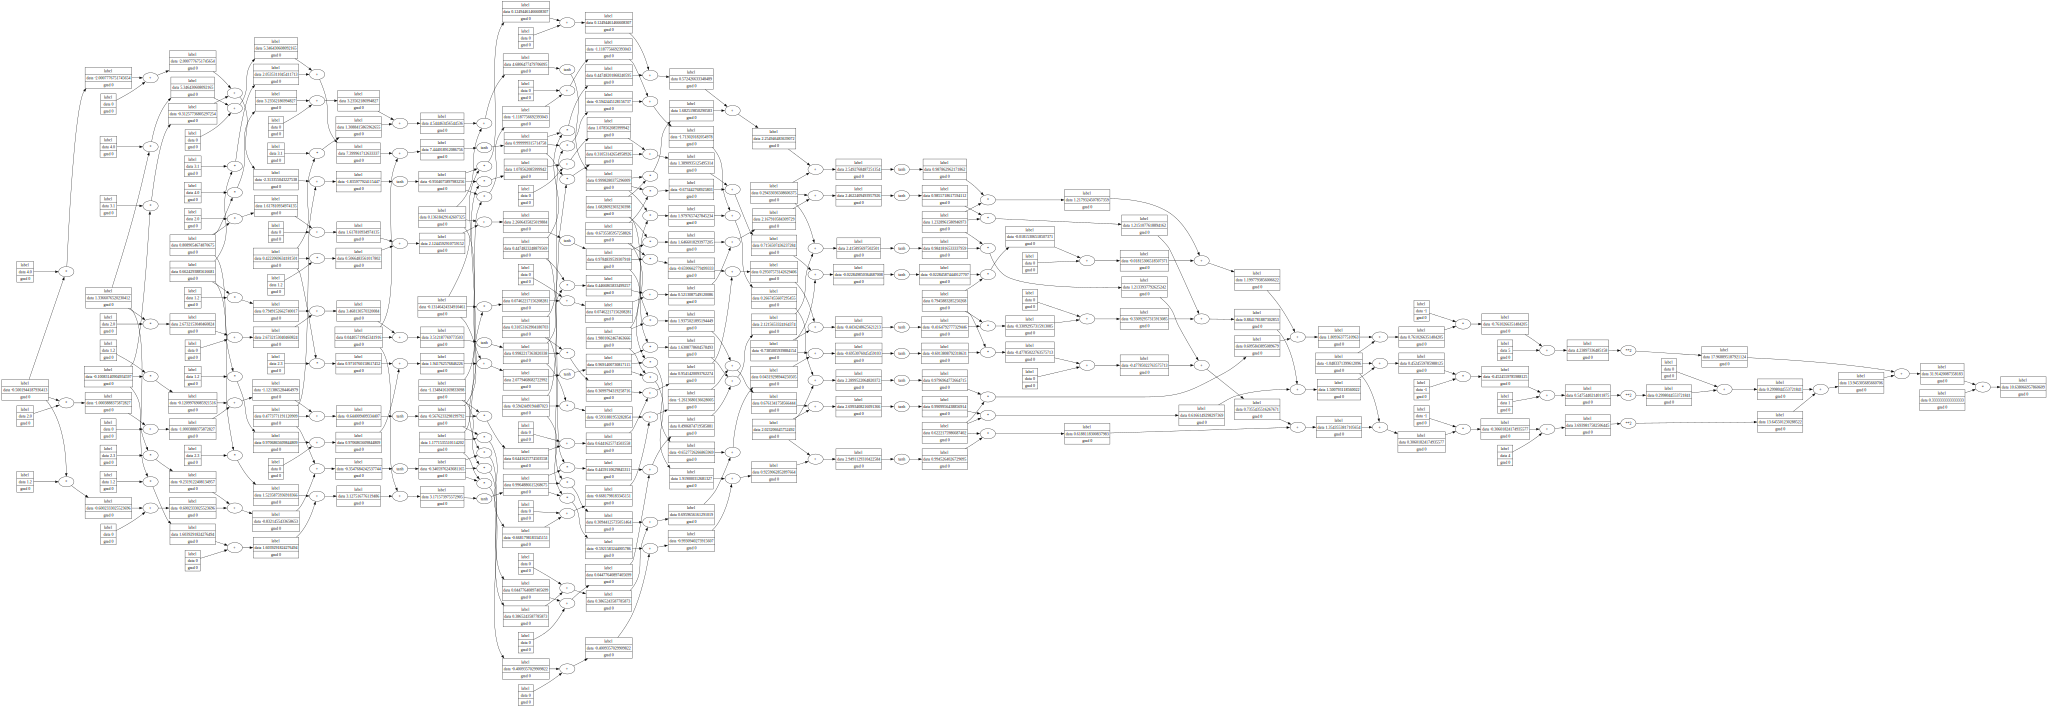

In [375]:
draw_dot(L)

In [ ]:
# forward_pass 
y_pred = [mlp(x_) for x_ in x]
# zero out gradients 


[Value(data = 0.4524559785988125),
 Value(data = 0.30601824174935577),
 Value(data = 0.7610266351484205)]